# 🔢 Sesión 5 (Frecuencia) — Sobredispersión y el modelo colectivo
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

**Semana 2 · Frecuencia** · **Herramienta:** Python
**Proyecto:** módulo de frecuencia de la nota técnica

---

> **Objetivo:** diagnosticar la **sobredispersión** (Var[N] > E[N]), ver sus salidas según la causa
> —**quasi-Poisson** (moderada), un vistazo a **ZIP** (exceso de ceros) y la **binomial negativa**
> (heterogeneidad)— y unir por fin frecuencia y severidad con $E[S]$ y $\operatorname{Var}[S]$.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las de Ejercicio las completas tú.**
> Todavía **sin simular**: solo momentos analíticos.

## Contenido
1. [Entorno](#1)
2. [Diagnóstico: media vs. varianza](#2)
3. [Exceso de ceros (y una nota sobre ZIP)](#3)
4. [Quasi-Poisson: el factor de dispersión φ](#4)
5. [Binomial negativa vs. Poisson (AIC)](#5)
6. [Unir las piezas: E[S] y Var[S]](#6)
7. [Cierre](#7)

---

---
<a id='1'></a>
## 1. Entorno

In [1]:
# ─── Entorno ────────────────────────────────────────────────────────────────
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

np.random.seed(3)
plt.rcParams["figure.figsize"] = (8, 3.8)
print("✓ listo")

✓ listo


---
<a id='2'></a>
## 2. Diagnóstico: media vs. varianza

Generamos los conteos de una cartera **heterogénea** (mezcla de dos grupos de riesgo) y medimos el
**índice de dispersión** Var/media. Si es claramente > 1, hay sobredispersión.

In [2]:
# ─── Conteos de una cartera heterogénea ────────────────────────────────────
conteos = np.concatenate([stats.poisson(0.15).rvs(7_000),   # grupo de bajo riesgo
                          stats.poisson(1.30).rvs(3_000)])  # grupo de alto riesgo
X = np.ones((len(conteos), 1))                              # solo intercepto (sin factores aún)

media, var = conteos.mean(), conteos.var()
print(f"media = {media:.4f}")
print(f"var   = {var:.4f}")
print(f"índice de dispersión = var/media = {var/media:.3f}   (>1 → SOBREDISPERSA)")

media = 0.4826
var   = 0.7627
índice de dispersión = var/media = 1.580   (>1 → SOBREDISPERSA)


### ✏️ Ejercicio 1 — confirma la sobredispersión

1. Calcula el índice de dispersión de `conteos`.
2. ¿Qué te dice sobre usar Poisson tal cual?

In [3]:
# Tu código aquí 👇
# Pista: conteos.var() / conteos.mean()


---
<a id='3'></a>
## 3. Exceso de ceros (y una nota sobre ZIP)

Buena parte de la sobredispersión en seguros viene de **demasiados ceros** (la mayoría no reclama).
Lo diagnosticamos comparando los ceros **observados** con los que **esperaría una Poisson**.

In [4]:
# ─── ¿Hay exceso de ceros? ─────────────────────────────────────────────────
lam = conteos.mean()
ceros_obs = (conteos == 0).mean()
ceros_pois = stats.poisson(lam).pmf(0)

print(f"P(N=0) observada        : {ceros_obs:.3f}")
print(f"P(N=0) esperada (Poisson): {ceros_pois:.3f}")
print(f"Exceso de ceros          : {ceros_obs - ceros_pois:+.3f}")
print("\nHay más ceros de los que la Poisson espera. Cuando esto domina, el modelo")
print("adecuado es un ZIP o un hurdle (modelan explícitamente ese exceso de ceros).")

P(N=0) observada        : 0.693
P(N=0) esperada (Poisson): 0.617
Exceso de ceros          : +0.076

Hay más ceros de los que la Poisson espera. Cuando esto domina, el modelo
adecuado es un ZIP o un hurdle (modelan explícitamente ese exceso de ceros).


### ✏️ Ejercicio 2 — mide el exceso de ceros

1. Calcula cuántas veces más frecuentes son los ceros observados que los esperados por Poisson
   (razón `ceros_obs / ceros_pois`).

In [5]:
# Tu código aquí 👇


---
<a id='4'></a>
## 4. Quasi-Poisson: el factor de dispersión φ

La quasi-Poisson no cambia la media: solo **infla la varianza** por un factor $\phi$, con
$\operatorname{Var}[N]=\phi\,\mu$. Se ajusta como un GLM Poisson con la escala estimada de Pearson.

In [6]:
# ─── Quasi-Poisson (GLM Poisson con escala Pearson) ────────────────────────
glm = sm.GLM(conteos, X, family=sm.families.Poisson()).fit(scale="X2")
phi = glm.scale
mu  = np.exp(glm.params[0])

print(f"μ (media)              = {mu:.4f}")
print(f"φ (factor dispersión)  = {phi:.3f}")
print(f"Var implícita = φ·μ     = {phi*mu:.4f}   (vs. var empírica {conteos.var():.4f})")
print(f"\nLos errores estándar se inflan por √φ = {np.sqrt(phi):.3f}:")
print("la media queda igual, pero la incertidumbre sobre ella es mayor. Ojo: la quasi-Poisson")
print("no tiene pmf propia, así que no la usamos para simular ni para la cola.")

μ (media)              = 0.4826
φ (factor dispersión)  = 1.581
Var implícita = φ·μ     = 0.7628   (vs. var empírica 0.7627)

Los errores estándar se inflan por √φ = 1.257:
la media queda igual, pero la incertidumbre sobre ella es mayor. Ojo: la quasi-Poisson
no tiene pmf propia, así que no la usamos para simular ni para la cola.


### ✏️ Ejercicio 3 — el precio de la dispersión

1. Con `phi`, calcula en qué **porcentaje** crecen los errores estándar (√φ − 1).

In [7]:
# Tu código aquí 👇
# Pista: (np.sqrt(phi) - 1)


---
<a id='5'></a>
## 5. Binomial negativa vs. Poisson (AIC)

Para la **heterogeneidad** (la causa de fondo), la binomial negativa. La ajustamos junto con la
Poisson y comparamos con el **AIC** (menor es mejor).

In [8]:
# ─── Ajuste Poisson vs. Binomial negativa ──────────────────────────────────
pois = sm.Poisson(conteos, X).fit(disp=0)
nb   = sm.NegativeBinomial(conteos, X).fit(disp=0)

print(f"AIC Poisson           = {pois.aic:,.1f}")
print(f"AIC Binomial negativa = {nb.aic:,.1f}")
print(f"→ Gana: {'Binomial negativa' if nb.aic < pois.aic else 'Poisson'}")

# parámetros de la NB en la parametrización (media μ, dispersión α)
mu_nb    = np.exp(nb.params[0])
alpha_nb = nb.params[-1]
r_nb     = 1 / alpha_nb
p_nb     = 1 / (1 + alpha_nb * mu_nb)
print(f"\nNB: μ={mu_nb:.3f}, α={alpha_nb:.3f}  →  Var[N]=μ+αμ²={mu_nb + alpha_nb*mu_nb**2:.3f}")

AIC Poisson           = 19,716.3
AIC Binomial negativa = 18,678.8
→ Gana: Binomial negativa

NB: μ=0.483, α=1.362  →  Var[N]=μ+αμ²=0.800


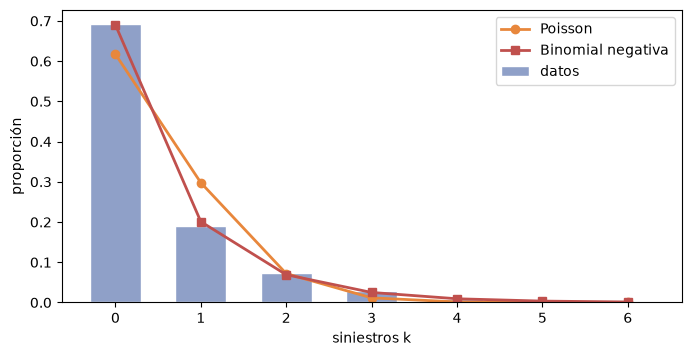

In [9]:
# ─── Observado vs. esperado: Poisson y NB ──────────────────────────────────
kmax = conteos.max(); ks = np.arange(0, kmax + 1)
obs  = np.bincount(conteos, minlength=kmax + 1) / len(conteos)
e_po = stats.poisson(mu_nb).pmf(ks)
e_nb = stats.nbinom(r_nb, p_nb).pmf(ks)

plt.bar(ks, obs, width=0.6, color="#8FA0C8", edgecolor="white", label="datos")
plt.plot(ks, e_po, "o-", color="#E8873C", lw=2, label="Poisson")
plt.plot(ks, e_nb, "s-", color="#C0504D", lw=2, label="Binomial negativa")
plt.xlabel("siniestros k"); plt.ylabel("proporción"); plt.xticks(ks); plt.legend(); plt.show()

### ✏️ Ejercicio 4 — ¿quién ajusta mejor los ceros?

1. Compara la proporción de ceros **observada** con la esperada por **Poisson** y por **NB**
   (`obs[0]`, `e_po[0]`, `e_nb[0]`). ¿Cuál se acerca más?

In [10]:
# Tu código aquí 👇


---
<a id='6'></a>
## 6. Unir las piezas: E[S] y Var[S]

Con la frecuencia ya elegida, juntamos con la **severidad** en el modelo colectivo. Recordando:

$$E[S]=E[N]\,E[X]\qquad \operatorname{Var}[S]=E[N]\operatorname{Var}[X]+\operatorname{Var}[N]\,E[X]^2$$

In [11]:
# ─── E[S] y Var[S] con Poisson vs. Binomial negativa ───────────────────────
sev = stats.lognorm(s=0.9, scale=180)          # severidad de la sesión anterior
EX, VarX = sev.mean(), sev.var()

EN = mu_nb                                      # misma media de frecuencia
VarN_pois = EN                                  # Poisson: Var = media
VarN_nb   = EN + alpha_nb * EN**2               # NB: Var > media

def colectivo(EN, VarN):
    ES  = EN * EX
    VarS = EN * VarX + VarN * EX**2
    return ES, VarS, np.sqrt(VarS)

print(f"Severidad: E[X]={EX:,.0f}  Var[X]={VarX:,.0f}")
print(f"Frecuencia: E[N]={EN:.3f}\n")
print(f"{'':16}{'E[S]':>10}{'Var[S]':>14}{'Desv.est.':>12}")
for nombre, VarN in [("Poisson", VarN_pois), ("Binomial neg.", VarN_nb)]:
    ES, VarS, DE = colectivo(EN, VarN)
    print(f"{nombre:16}{ES:>10,.1f}{VarS:>14,.0f}{DE:>12,.1f}")
print("\nMisma prima esperada E[S], pero la NB da más Var[S]: más riesgo, más capital.")

Severidad: E[X]=270  Var[X]=90,888
Frecuencia: E[N]=0.483

                      E[S]        Var[S]   Desv.est.
Poisson              130.2        79,011       281.1
Binomial neg.        130.2       102,113       319.6

Misma prima esperada E[S], pero la NB da más Var[S]: más riesgo, más capital.


### ✏️ Ejercicio 5 — la varianza tiene dos fuentes

1. Con la NB, calcula qué porcentaje de `Var[S]` viene del término del **conteo**
   (`Var[N]·E[X]²`) vs. el de la **severidad** (`E[N]·Var[X]`).

In [12]:
# Tu código aquí 👇
# Pista: VarN_nb*EX**2  y  EN*VarX


---
<a id='7'></a>
## 7. Cierre

Diagnosticamos la sobredispersión y elegimos la herramienta según su causa: **quasi-Poisson**
(moderada), **ZIP/hurdle** (exceso de ceros) y **binomial negativa** (heterogeneidad). Y unimos
frecuencia con severidad en $E[S]$ y $\operatorname{Var}[S]$.

**Próxima semana:** la **distribución completa** de $S$ (convolución, Panjer y simulación) — ahí sí
se simula.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Semana 2 · Sesión 5*